In [4]:
import os
import glob
from collections import defaultdict
import re
import rasterio
from rasterio.transform import Affine
from rasterio.windows import Window
from rasterio.transform import rowcol
import rioxarray
import xarray as xr
import numpy as np
import pdb
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
def build_union_grid(rasters, res=None):
    """Compute union extent and create a target grid."""
    bounds = []
    resolutions = []
    for f in rasters:
        da = rioxarray.open_rasterio(f).squeeze()
        bounds.append(da.rio.bounds())
        resolutions.append(da.rio.resolution())
    minx = min(b[0] for b in bounds)
    miny = min(b[1] for b in bounds)
    maxx = max(b[2] for b in bounds)
    maxy = max(b[3] for b in bounds)

    # Pick resolution (finest among all rasters if not specified)
    if res is None:
        resx = min(abs(r[0]) for r in resolutions)
        resy = min(abs(r[1]) for r in resolutions)
    else:
        resx, resy = res

    # Build coordinates
    xs = np.arange(minx, maxx + resx, resx)
    ys = np.arange(maxy, miny - resy, -resy)  # descending
    target = xr.DataArray(
        np.empty((len(ys), len(xs))),
        coords={"y": ys, "x": xs},
        dims=("y", "x"),
    )
    target.rio.write_crs("EPSG:4326", inplace=True)
    return target

folder = Path("D:/MyDrive/Stability/RawData/Monthly_Averages/Chukchi")

out_dir = folder / "WeightedMeans_Union"
out_dir.mkdir(exist_ok=True)

pat = re.compile(r"^(.*?)_Monthly_(Count|Mean)_(\d+)\.tif$")
by_month = defaultdict(lambda: {"Count": [], "Mean": []})

for f in folder.glob("*.tif"):
    m = pat.match(f.name)
    if m:
        region, ftype, month = m.groups()
        by_month[month][ftype].append(f)


for month, groups in sorted(by_month.items()):
    files = groups["Count"] + groups["Mean"]
    if not files:
        continue

    # Build union grid for this month
    target_grid = build_union_grid(files)

    weighted_sum = None
    total_count = None

    for cfile, mfile in zip(sorted(groups["Count"]), sorted(groups["Mean"])):
        count = rioxarray.open_rasterio(cfile, masked=True).squeeze()
        mean  = rioxarray.open_rasterio(mfile, masked=True).squeeze()

        # Mask pixels where count <= 1
        mask = count <= 1
        count = count.where(~mask)
        mean  = mean.where(~mask)

        # Reproject to union grid
        count = count.rio.reproject_match(target_grid)
        mean  = mean.rio.reproject_match(target_grid)

        weighted = mean * count

        if weighted_sum is None:
            weighted_sum = weighted
            total_count  = count
        else:
            # Sum while preserving NaNs
            weighted_sum = xr.concat([weighted_sum, weighted], dim="new").sum(dim="new", skipna=True)
            total_count  = xr.concat([total_count, count], dim="new").sum(dim="new", skipna=True)

    # Final weighted mean: only compute where total_count >= 1
    weighted_mean = weighted_sum / total_count
    weighted_mean = weighted_mean.where(total_count > 1)  # NaN where no coverage

    out_file = out_dir / f"WeightedMean_{month}.tif"
    #pdb.set_trace()
    weighted_mean.rio.to_raster(out_file, compress="deflate")
    print(f"{out_file}")

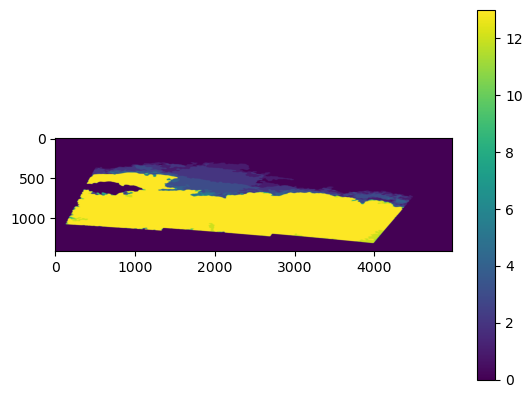

In [21]:
for month, groups in sorted(by_month.items()):
    files = groups["Count"] + groups["Mean"]
    if not files:
        continue

    # Build union grid for this month
    target_grid = build_union_grid(files)

    weighted_sum = xr.zeros_like(target_grid)
    total_count  = xr.zeros_like(target_grid)

    for cfile, mfile in zip(sorted(groups["Count"]), sorted(groups["Mean"])):
        count = rioxarray.open_rasterio(cfile, masked=True).squeeze()
        mean  = rioxarray.open_rasterio(mfile, masked=True).squeeze()

        # Mask pixels where count <= 1
        mask = count <= 1
        count = count.where(~mask, 0)  # set low-count pixels to 0
        mean  = mean.where(~mask, 0)

        # Reproject to union grid
        count = count.rio.reproject_match(target_grid)
        mean  = mean.rio.reproject_match(target_grid)

        weighted = mean * count

        # Add while ignoring NaNs
        weighted_sum = weighted_sum + weighted.fillna(0)
        total_count  = total_count + count.fillna(0)

    # Final weighted mean: only compute where total_count >= 1
    weighted_mean = xr.where(total_count > 0, weighted_sum / total_count, np.nan)

    out_file = out_dir / f"WeightedMean_{month}.tif"
    weighted_mean.rio.to_raster(out_file, compress="deflate")
    print(f"{out_file}")test = rioxarray.open_rasterio("D:/MyDrive/Stability/RawData/Monthly_Averages/Colville_Delta_Monthly_Count_01.tif").squeeze()
plt.imshow(test)
plt.colorbar()